In [1]:
# ============================================================
# IMPORTACIONES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# CONFIGURACIÓN VISUAL
# ============================================================

plt.rcParams["figure.figsize"] = (14, 6)


# ============================================================
# CARGA DATASET
# ============================================================

df = pd.read_parquet(
    "../data/processed/bdlona_logs.parquet"
)


# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

print(df.shape)

display(df.head())


# ============================================================
# TIPOS DE DATOS
# ============================================================

df.info()


# ============================================================
# ESTADÍSTICAS BÁSICAS
# ============================================================

df.describe()

(298674, 9)


,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file
0,2010-01-01 08:00:07,BDLONA,10,267,11,4,19,1,100101.log
1,2010-01-01 08:15:09,BDLONA,11,279,9,3,18,1,100101.log
2,2010-01-01 08:30:01,BDLONA,11,270,10,4,17,1,100101.log
3,2010-01-01 08:45:04,BDLONA,11,269,10,3,22,1,100101.log
4,2010-01-01 09:00:07,BDLONA,11,278,9,1,21,1,100101.log


<class 'pandas.DataFrame'>
RangeIndex: 298674 entries, 0 to 298673
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   datetime            298674 non-null  datetime64[us]
 1   spot                298674 non-null  str           
 2   temperature         298674 non-null  int64         
 3   wind_direction_deg  298674 non-null  int64         
 4   wind_avg            298674 non-null  int64         
 5   wind_min            298674 non-null  int64         
 6   wind_max            298674 non-null  int64         
 7   unknown             298674 non-null  int64         
 8   source_file         298674 non-null  str           
dtypes: datetime64[us](1), int64(6), str(2)
memory usage: 25.1 MB


,datetime,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown
count,298674,298674.000000,298674.000000,298674.000000,298674.000000,298674.000000,298674.000000
mean,2018-02-01 19:38:13.438046,19.424423,182.070050,5.532688,3.062011,8.596523,0.572805
min,2010-01-01 08:00:07,-16.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014-03-17 17:03:47.750000,15.000000,104.000000,2.000000,0.000000,5.000000,0.000000
50%,2018-02-17 15:23:05.500000,19.000000,185.000000,5.000000,2.000000,8.000000,1.000000
75%,2022-02-08 18:26:17.750000,25.000000,263.000000,8.000000,5.000000,11.000000,1.000000
max,2025-12-31 19:00:04,34.000000,359.000000,36.000000,28.000000,87.000000,1.000000
std,NaN,5.983596,88.321396,4.365525,3.553620,5.270719,0.494672


In [2]:
# ============================================================
# FEATURES TEMPORALES
# ============================================================

df["year"] = df["datetime"].dt.year

df["month"] = df["datetime"].dt.month

df["day"] = df["datetime"].dt.day

df["hour"] = df["datetime"].dt.hour

df["weekday"] = df["datetime"].dt.day_name()


# ============================================================
# COMPROBAR RESULTADO
# ============================================================

df.head()

,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file,year,month,day,hour,weekday
0,2010-01-01 08:00:07,BDLONA,10,267,11,4,19,1,100101.log,2010,1,1,8,Friday
1,2010-01-01 08:15:09,BDLONA,11,279,9,3,18,1,100101.log,2010,1,1,8,Friday
2,2010-01-01 08:30:01,BDLONA,11,270,10,4,17,1,100101.log,2010,1,1,8,Friday
3,2010-01-01 08:45:04,BDLONA,11,269,10,3,22,1,100101.log,2010,1,1,8,Friday
4,2010-01-01 09:00:07,BDLONA,11,278,9,1,21,1,100101.log,2010,1,1,9,Friday


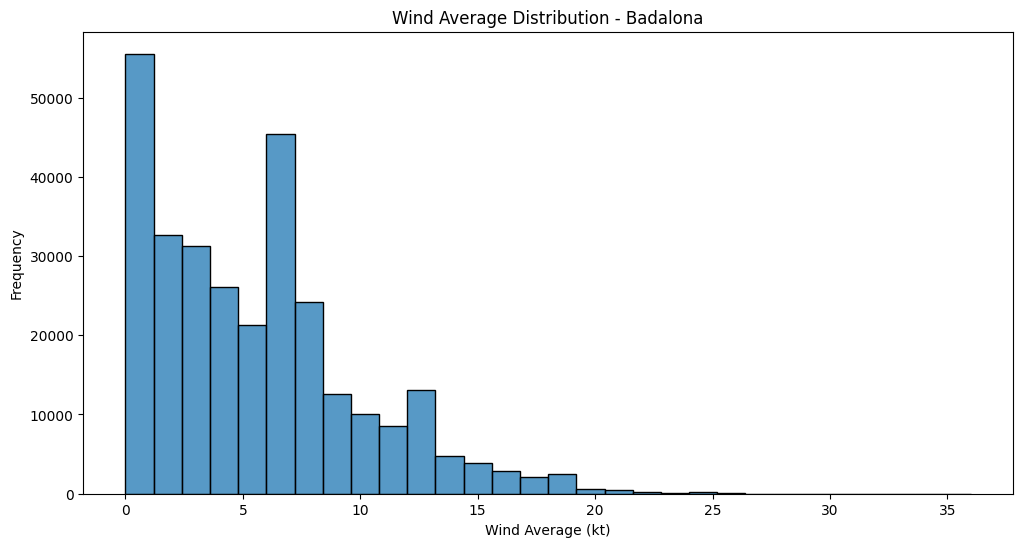

In [3]:
# ============================================================
# HISTOGRAMA VIENTO MEDIO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df,
    x="wind_avg",
    bins=30,
    ax=ax
)

ax.set_title("Wind Average Distribution - Badalona")

ax.set_xlabel("Wind Average (kt)")

ax.set_ylabel("Frequency")

plt.show()

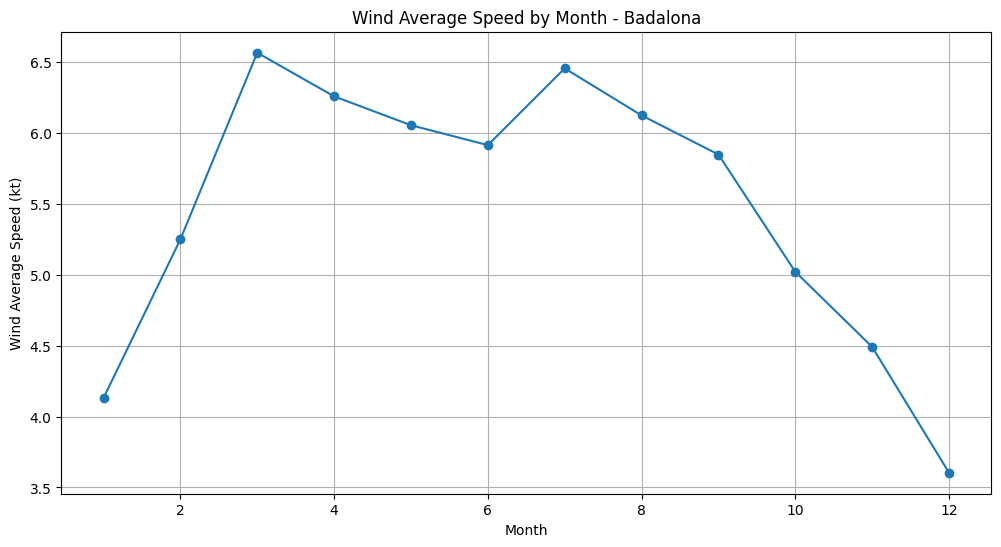

In [4]:
# ============================================================
# VIENTO MEDIO POR MES
# ============================================================

monthly_wind = (
    df.groupby("month")["wind_avg"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

monthly_wind.plot(
    marker="o",
    ax=ax
)

ax.set_title("Wind Average Speed by Month - Badalona")

ax.set_xlabel("Month")

ax.set_ylabel("Wind Average Speed (kt)")

ax.grid(True)

plt.show()

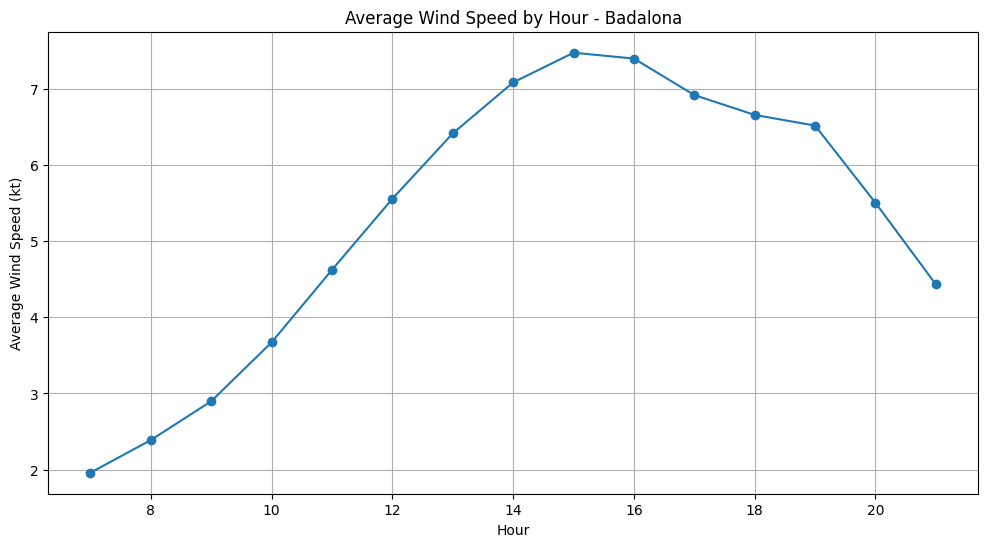

In [5]:
# ============================================================
# AVERAGE WIND SPEED BY HOUR
# ============================================================

hourly_wind = (
    df.groupby("hour")["wind_avg"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

hourly_wind.plot(
    marker="o",
    ax=ax
)

ax.set_title("Average Wind Speed by Hour - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.grid(True)

plt.show()

In [6]:
# ============================================================
# FILTER THERMAL WIND DIRECTIONS
# ============================================================

thermal_df = df[
    (df["wind_direction_deg"] >= 180) &
    (df["wind_direction_deg"] <= 225)
].copy()


print(thermal_df.shape)

thermal_df.head()

(65291, 14)


,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file,year,month,day,hour,weekday
101,2010-01-02 14:45:07,BDLONA,12,223,0,0,2,0,100102.log,2010,1,2,14,Saturday
136,2010-01-03 13:15:05,BDLONA,12,210,1,0,4,0,100103.log,2010,1,3,13,Sunday
142,2010-01-03 14:45:06,BDLONA,13,209,6,2,8,0,100103.log,2010,1,3,14,Sunday
143,2010-01-03 15:00:08,BDLONA,13,202,6,4,7,0,100103.log,2010,1,3,15,Sunday
144,2010-01-03 15:15:00,BDLONA,12,202,6,5,7,0,100103.log,2010,1,3,15,Sunday


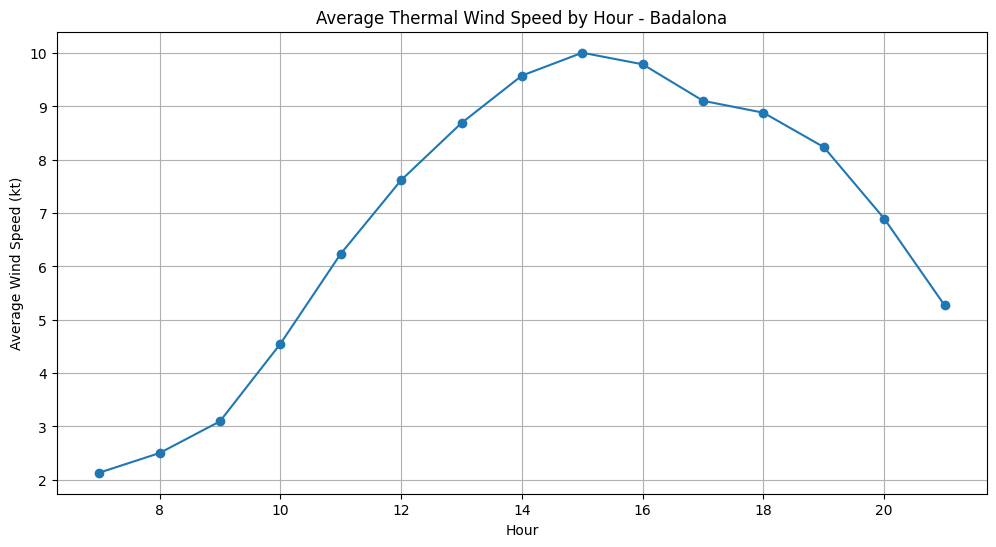

In [7]:
# ============================================================
# AVERAGE THERMAL WIND SPEED BY HOUR
# ============================================================

hourly_thermal_wind = (
    thermal_df.groupby("hour")["wind_avg"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

hourly_thermal_wind.plot(
    marker="o",
    ax=ax
)

ax.set_title("Average Thermal Wind Speed by Hour - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.grid(True)

plt.show()

In [8]:
# ============================================================
# CREATE SEASON FEATURE
# ============================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["season"] = df["month"].apply(get_season)

thermal_df["season"] = thermal_df["month"].apply(get_season)


# ============================================================
# CHECK RESULT
# ============================================================

df[["month", "season"]].head()

,month,season
0,1,Winter
1,1,Winter
2,1,Winter
3,1,Winter
4,1,Winter


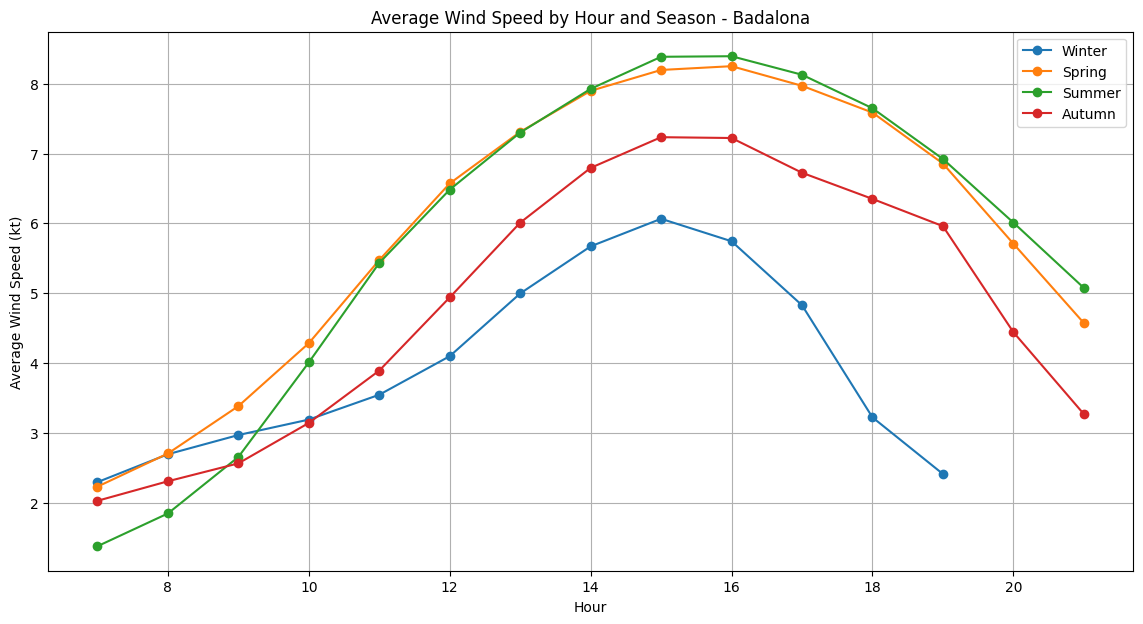

In [9]:
# ============================================================
# AVERAGE WIND SPEED BY HOUR AND SEASON
# ============================================================

seasonal_hourly_wind = (
    df.groupby(["season", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

for season in ["Winter", "Spring", "Summer", "Autumn"]:

    season_data = seasonal_hourly_wind[
        seasonal_hourly_wind["season"] == season
    ]

    ax.plot(
        season_data["hour"],
        season_data["wind_avg"],
        marker="o",
        label=season
    )

ax.set_title("Average Wind Speed by Hour and Season - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.legend()

ax.grid(True)

plt.show()

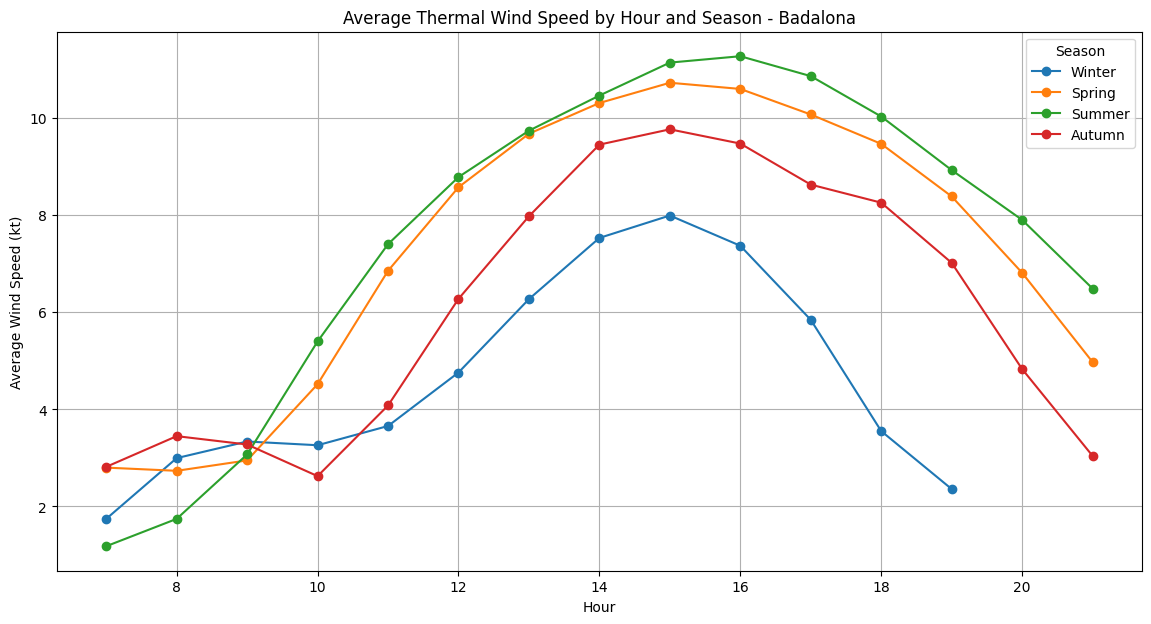

In [10]:
# ============================================================
# AVERAGE THERMAL WIND SPEED BY HOUR AND SEASON
# ============================================================

seasonal_thermal_hourly_wind = (
    thermal_df.groupby(["season", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

for season in ["Winter", "Spring", "Summer", "Autumn"]:

    season_data = seasonal_thermal_hourly_wind[
        seasonal_thermal_hourly_wind["season"] == season
    ]

    ax.plot(
        season_data["hour"],
        season_data["wind_avg"],
        marker="o",
        label=season
    )

ax.set_title("Average Thermal Wind Speed by Hour and Season - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.legend(title="Season")

ax.grid(True)

plt.show()

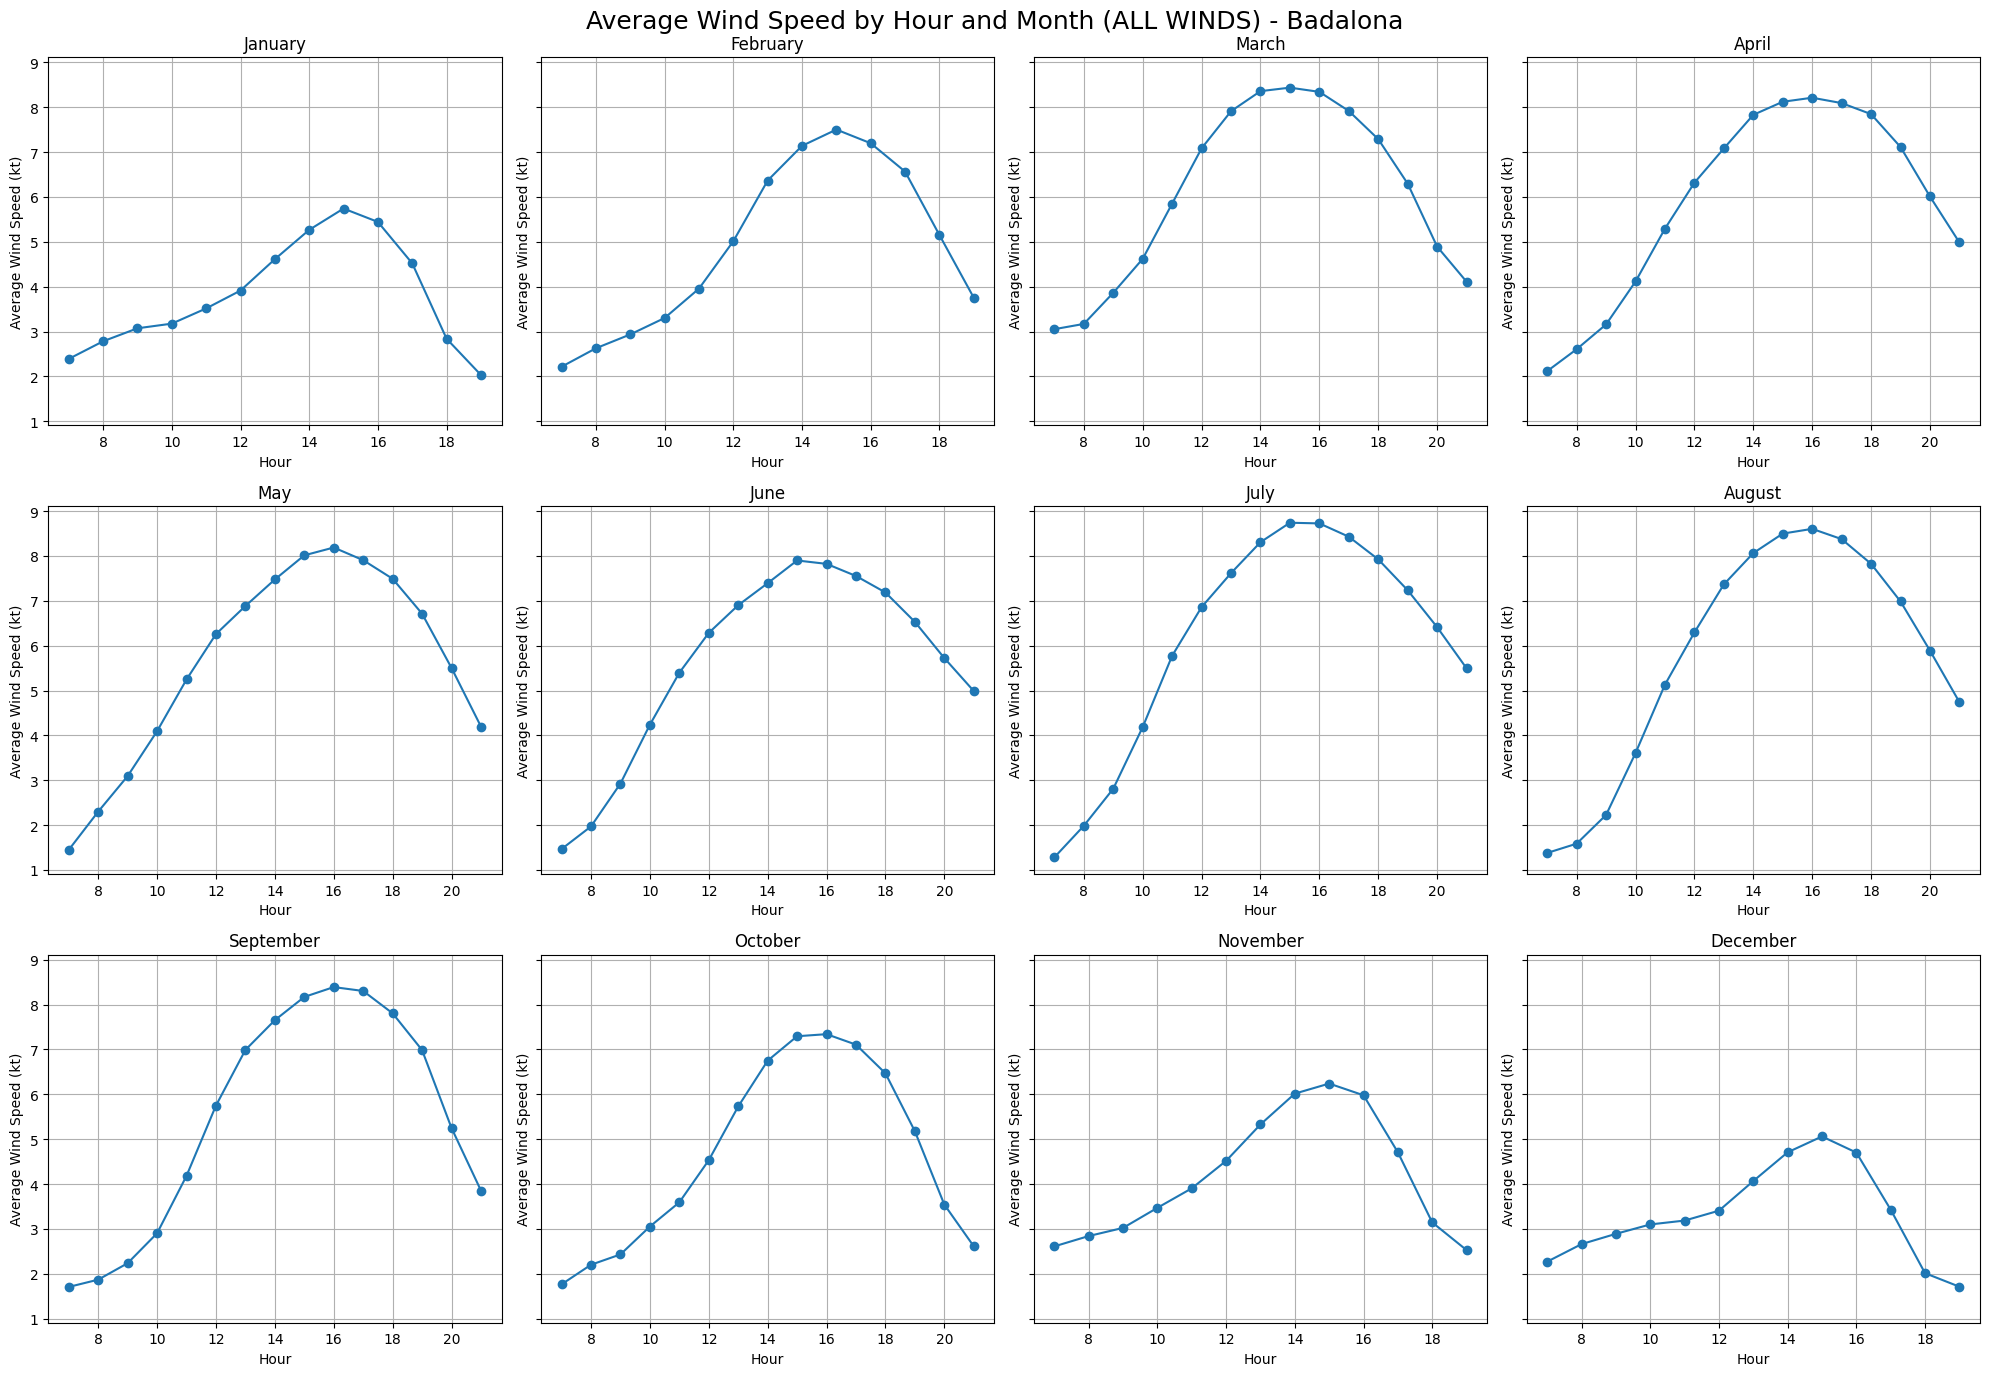

In [13]:
# ============================================================
# AVERAGE WIND SPEED BY HOUR AND MONTH
# ALL WINDS
# ============================================================

monthly_hourly_wind = (
    df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 14),
    sharey=True
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Month names
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in range(1, 13):

    ax = axes[month - 1]

    month_data = monthly_hourly_wind[
        monthly_hourly_wind["month"] == month
    ]

    ax.plot(
        month_data["hour"],
        month_data["wind_avg"],
        marker="o"
    )

    ax.set_title(month_names[month])

    ax.set_xlabel("Hour")

    ax.set_ylabel("Average Wind Speed (kt)")

    ax.grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Average Wind Speed by Hour and Month (ALL WINDS) - Badalona",
    fontsize=18
)

plt.tight_layout()

plt.show()

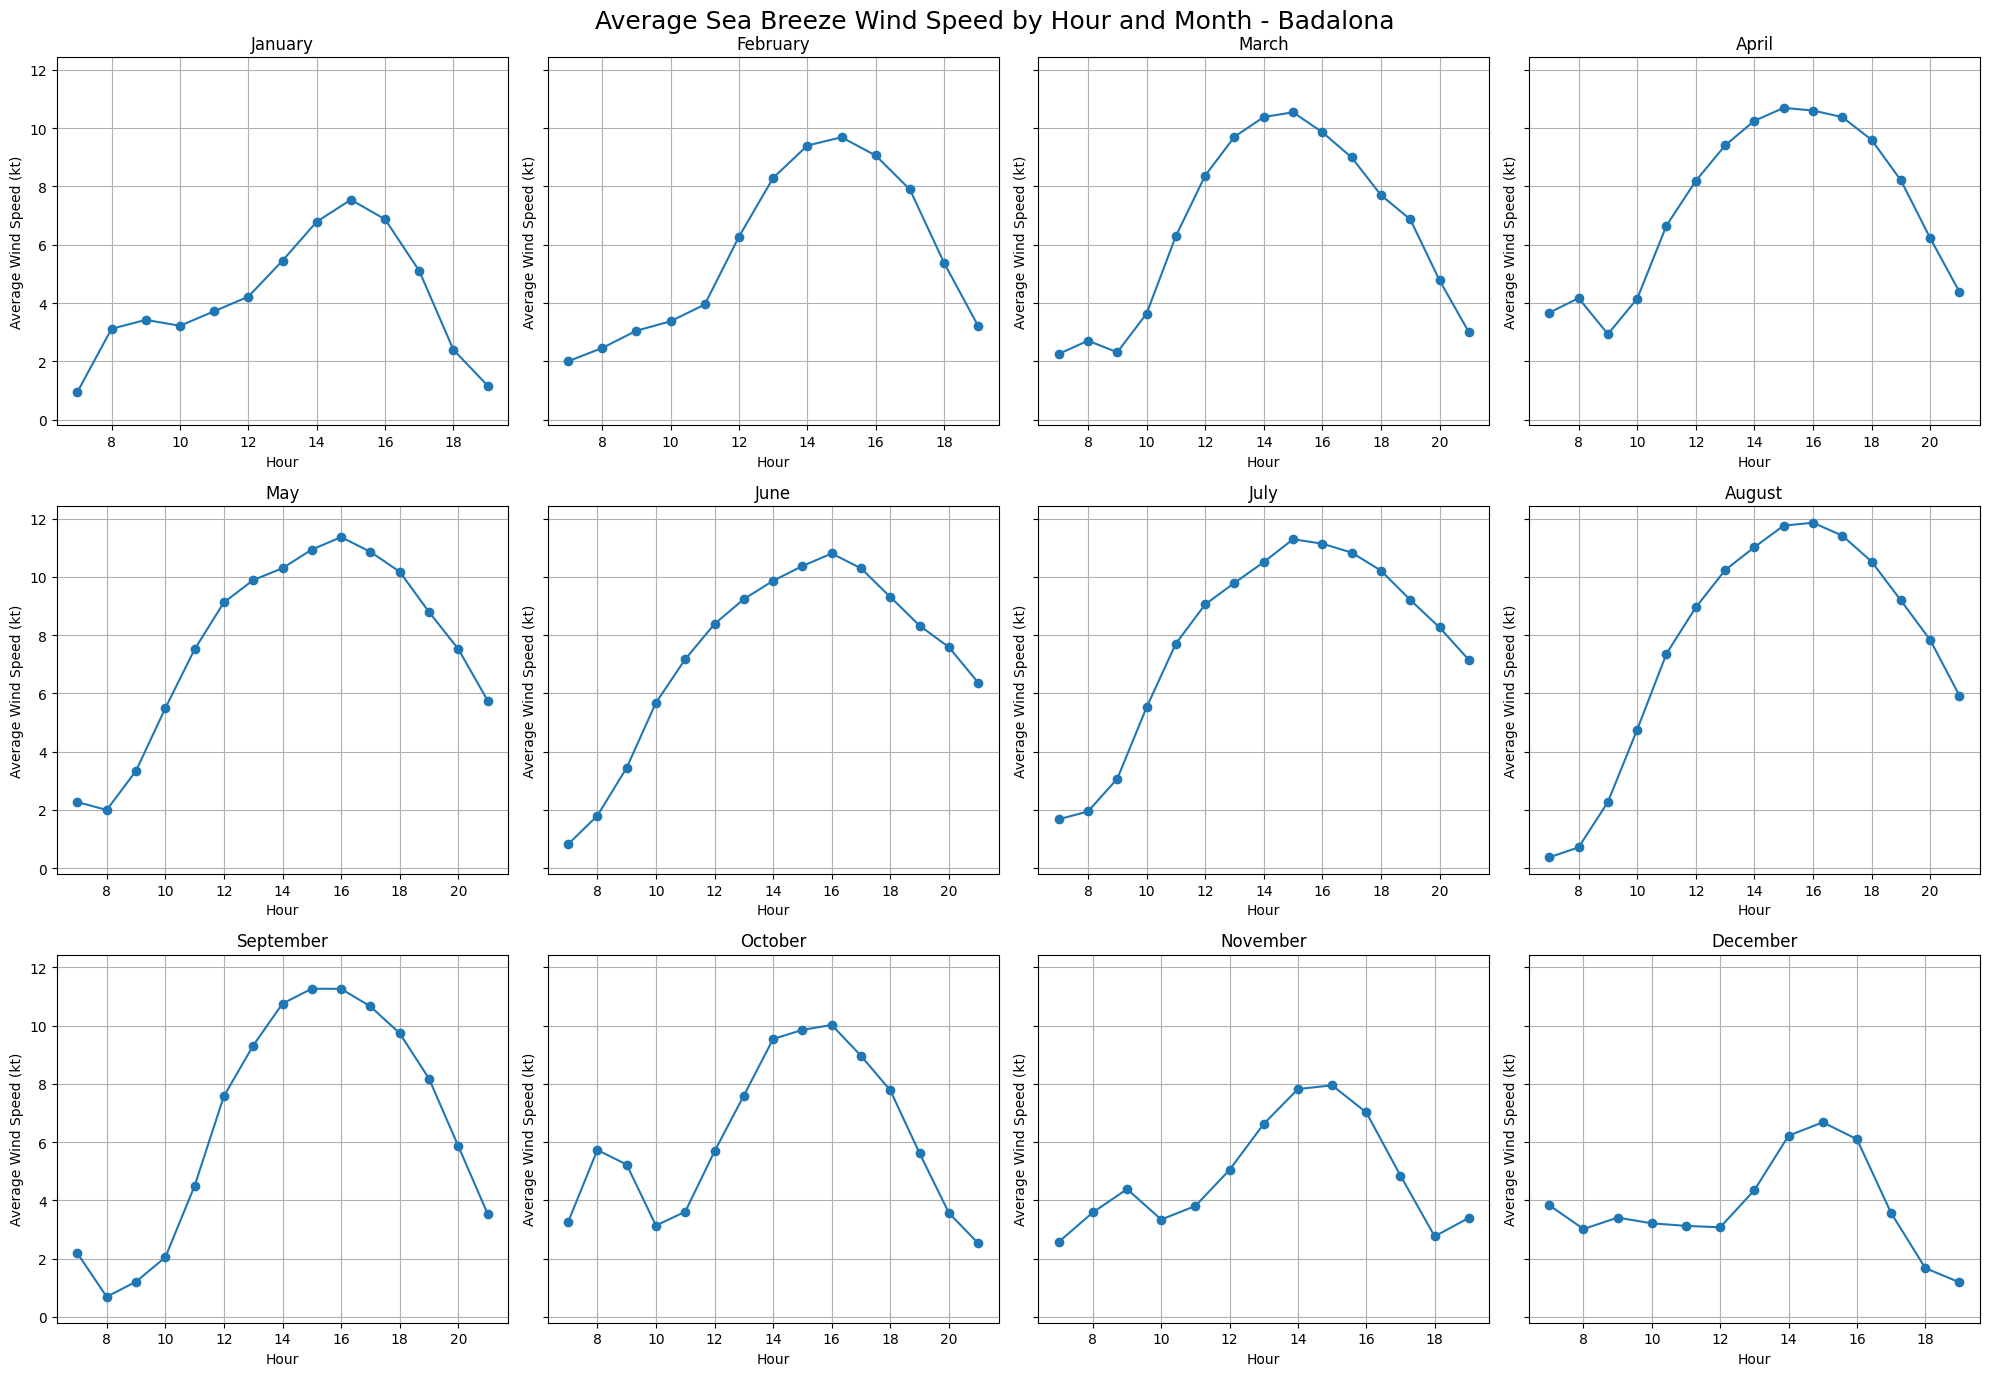

In [12]:
# ============================================================
# AVERAGE SEA BREEZE WIND SPEED BY HOUR AND MONTH
# ============================================================

monthly_hourly_sea_breeze = (
    thermal_df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 14),
    sharey=True
)

# Flatten axes
axes = axes.flatten()

# Month names
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in range(1, 13):

    ax = axes[month - 1]

    month_data = monthly_hourly_sea_breeze[
        monthly_hourly_sea_breeze["month"] == month
    ]

    ax.plot(
        month_data["hour"],
        month_data["wind_avg"],
        marker="o"
    )

    ax.set_title(month_names[month])

    ax.set_xlabel("Hour")

    ax.set_ylabel("Average Wind Speed (kt)")

    ax.grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Average Sea Breeze Wind Speed by Hour and Month - Badalona",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [14]:
# ============================================================
# OTHER WIND DIRECTIONS
# ============================================================

other_wind_df = df[
    ~(
        (df["wind_direction_deg"] >= 180) &
        (df["wind_direction_deg"] <= 225)
    )
].copy()


print(other_wind_df.shape)

(233383, 15)


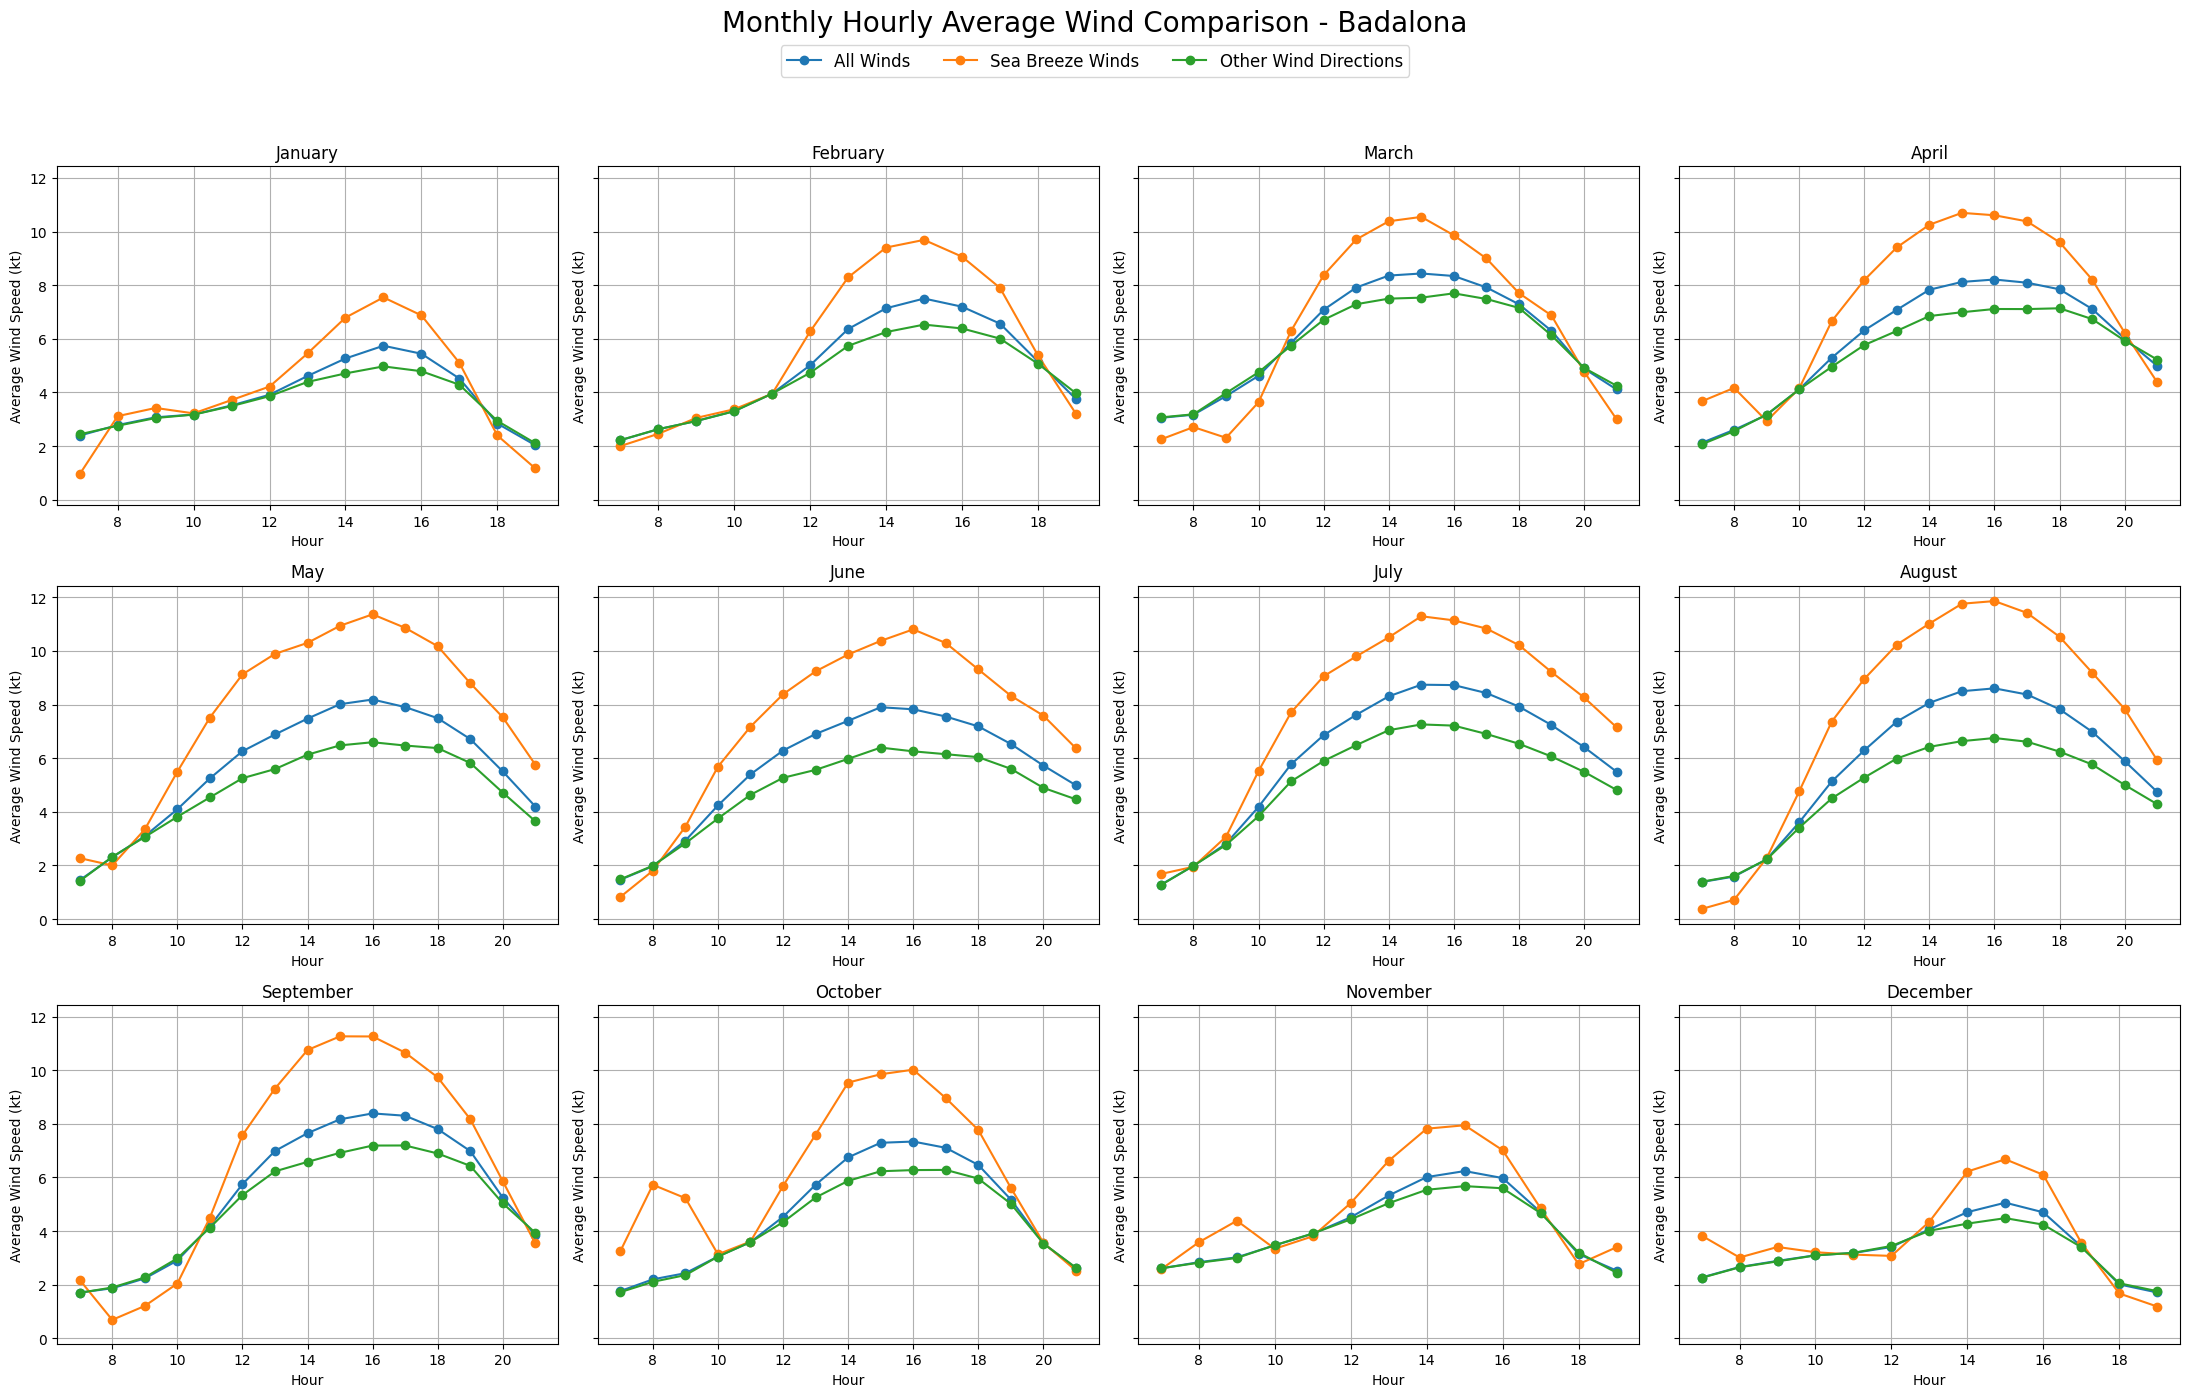

In [15]:
# ============================================================
# MONTHLY HOURLY WIND COMPARISON
# ALL WINDS vs SEA BREEZE vs OTHER DIRECTIONS
# ============================================================

# ============================================================
# GROUP DATA
# ============================================================

all_monthly = (
    df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

sea_breeze_monthly = (
    thermal_df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

other_monthly = (
    other_wind_df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(22, 14),
    sharey=True
)

axes = axes.flatten()

# ============================================================
# MONTH NAMES
# ============================================================

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in range(1, 13):

    ax = axes[month - 1]

    # -------------------------
    # ALL WINDS
    # -------------------------

    all_data = all_monthly[
        all_monthly["month"] == month
    ]

    ax.plot(
        all_data["hour"],
        all_data["wind_avg"],
        marker="o",
        label="All Winds"
    )

    # -------------------------
    # SEA BREEZE WINDS
    # -------------------------

    sea_data = sea_breeze_monthly[
        sea_breeze_monthly["month"] == month
    ]

    ax.plot(
        sea_data["hour"],
        sea_data["wind_avg"],
        marker="o",
        label="Sea Breeze Winds"
    )

    # -------------------------
    # OTHER WIND DIRECTIONS
    # -------------------------

    other_data = other_monthly[
        other_monthly["month"] == month
    ]

    ax.plot(
        other_data["hour"],
        other_data["wind_avg"],
        marker="o",
        label="Other Wind Directions"
    )

    # -------------------------
    # TITLES & LABELS
    # -------------------------

    ax.set_title(month_names[month])

    ax.set_xlabel("Hour")

    ax.set_ylabel("Average Wind Speed (kt)")

    ax.grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Monthly Hourly Average Wind Comparison - Badalona",
    fontsize=20,
    y=0.995
)

# ============================================================
# GLOBAL LEGEND
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=3,
    fontsize=12
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.show()

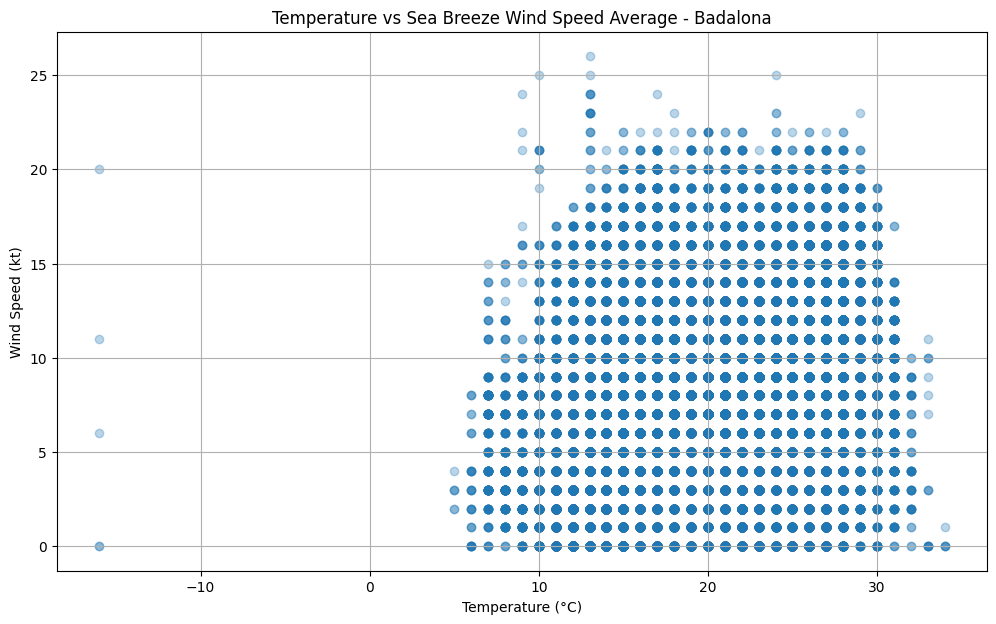

In [16]:
# ============================================================
# TEMPERATURE VS SEA BREEZE WIND SPEED
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    thermal_df["temperature"],
    thermal_df["wind_avg"],
    alpha=0.3
)

ax.set_title(
    "Temperature vs Sea Breeze Wind Speed Average - Badalona"
)

ax.set_xlabel("Temperature (°C)")

ax.set_ylabel("Wind Speed (kt)")

ax.grid(True)

plt.show()

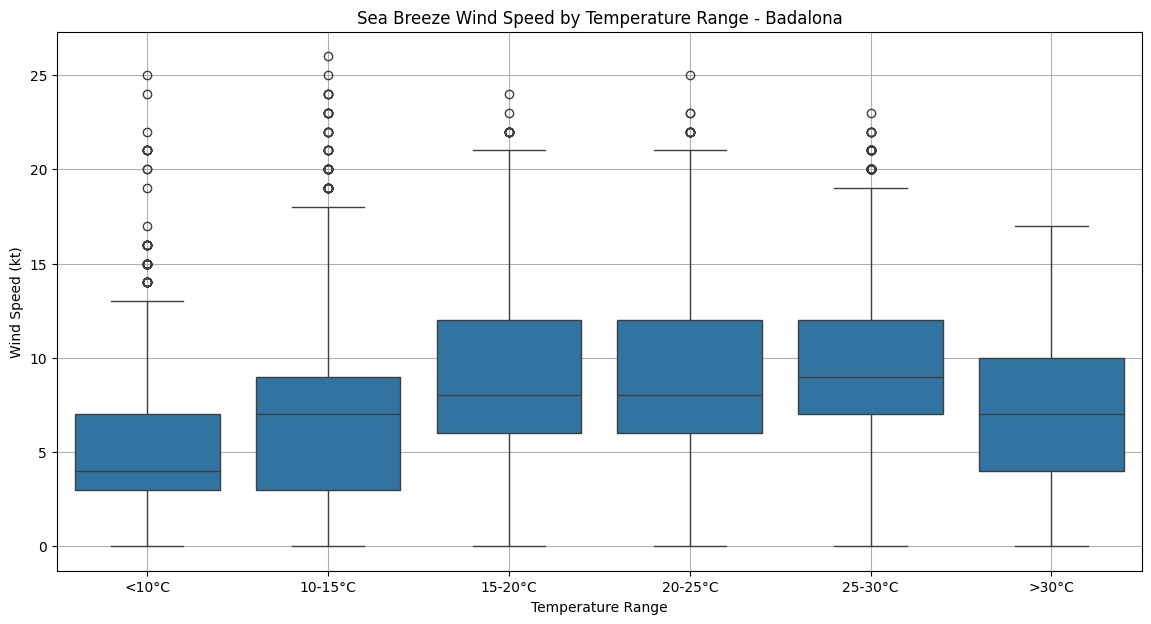

In [17]:
# ============================================================
# TEMPERATURE BINS
# ============================================================

temperature_bins = [0, 10, 15, 20, 25, 30, 40]

temperature_labels = [
    "<10°C",
    "10-15°C",
    "15-20°C",
    "20-25°C",
    "25-30°C",
    ">30°C"
]

thermal_df["temperature_range"] = pd.cut(
    thermal_df["temperature"],
    bins=temperature_bins,
    labels=temperature_labels
)

# ============================================================
# BOXPLOT
# TEMPERATURE VS SEA BREEZE WIND SPEED
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=thermal_df,
    x="temperature_range",
    y="wind_avg",
    ax=ax
)

ax.set_title(
    "Sea Breeze Wind Speed by Temperature Range - Badalona"
)

ax.set_xlabel("Temperature Range")

ax.set_ylabel("Wind Speed (kt)")

ax.grid(True)

plt.show()

In [18]:
thermal_df

,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file,year,month,day,hour,weekday,season,temperature_range
101,2010-01-02 14:45:07,BDLONA,12,223,0,0,2,0,100102.log,2010,1,2,14,Saturday,Winter,10-15°C
136,2010-01-03 13:15:05,BDLONA,12,210,1,0,4,0,100103.log,2010,1,3,13,Sunday,Winter,10-15°C
142,2010-01-03 14:45:06,BDLONA,13,209,6,2,8,0,100103.log,2010,1,3,14,Sunday,Winter,10-15°C
143,2010-01-03 15:00:08,BDLONA,13,202,6,4,7,0,100103.log,2010,1,3,15,Sunday,Winter,10-15°C
144,2010-01-03 15:15:00,BDLONA,12,202,6,5,7,0,100103.log,2010,1,3,15,Sunday,Winter,10-15°C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298567,2025-12-29 17:00:00,BDLONA,12,180,0,0,3,1,251229.log,2025,12,29,17,Monday,Winter,10-15°C
298570,2025-12-29 17:45:02,BDLONA,12,195,0,0,2,1,251229.log,2025,12,29,17,Monday,Winter,10-15°C
298654,2025-12-31 14:15:06,BDLONA,11,223,3,0,6,1,251231.log,2025,12,31,14,Wednesday,Winter,10-15°C
298655,2025-12-31 14:30:07,BDLONA,11,199,3,0,6,1,251231.log,2025,12,31,14,Wednesday,Winter,10-15°C


In [19]:
# ============================================
# EXPORT BUSCAVIENTO SAMPLE + INFO
# ============================================

from pathlib import Path

# --------------------------------------------
# OUTPUT DIRECTORY
# --------------------------------------------

output_dir = Path(
    "/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================
# EXPORT FIRST 10 ROWS
# ============================================

wind_sample = thermal_df.head(10)

sample_path = output_dir / "buscaviento_sample_10rows.csv"

wind_sample.to_csv(
    sample_path,
    index=True
)

print("Sample exported:")
print(sample_path)

# ============================================
# EXPORT DTYPES
# ============================================

dtypes_df = pd.DataFrame({
    "column": thermal_df.columns,
    "dtype": thermal_df.dtypes.astype(str)
})

dtypes_path = output_dir / "buscaviento_dtypes.csv"

dtypes_df.to_csv(
    dtypes_path,
    index=False
)

print("\nDtypes exported:")
print(dtypes_path)

# ============================================
# EXPORT COLUMN LIST
# ============================================

columns_df = pd.DataFrame({
    "columns": thermal_df.columns
})

columns_path = output_dir / "buscaviento_columns.csv"

columns_df.to_csv(
    columns_path,
    index=False
)

print("\nColumns exported:")
print(columns_path)

# ============================================
# BASIC INFO
# ============================================

print("\nDataset shape:")
print(thermal_df.shape)

print("\nDate range:")

try:
    print(thermal_df.index.min())
    print(thermal_df.index.max())
except:
    print("No datetime index detected")

Sample exported:
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples/buscaviento_sample_10rows.csv

Dtypes exported:
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples/buscaviento_dtypes.csv

Columns exported:
/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/03_Especialitzacio/Project/thermal-wind-prediction/data/samples/buscaviento_columns.csv

Dataset shape:
(65291, 16)

Date range:
101
298656


In [22]:
# =========================================================
# CREATE WIND REGIME COLUMN
# =========================================================

df_export = df.copy()

# ---------------------------------------------------------
# Function to classify wind regimes
# ---------------------------------------------------------

def classify_wind_regime(direction):

    if pd.isna(direction):
        return "unknown"

    # Northerly
    if 0 <= direction < 60:
        return "northerly"

    # Easterly
    elif 60 <= direction < 140:
        return "easterly"

    # Sea Breeze
    elif 140 <= direction < 250:
        return "sea_breeze"

    # Westerly
    elif 250 <= direction <= 360:
        return "westerly"

    else:
        return "unknown"


# ---------------------------------------------------------
# Apply classification
# ---------------------------------------------------------

df_export["wind_regime"] = (
    df_export["wind_direction_deg"]
    .apply(classify_wind_regime)
    .astype("category")
)

# ---------------------------------------------------------
# Binary target for ML
# ---------------------------------------------------------

df_export["is_sea_breeze"] = (
    (df_export["wind_regime"] == "sea_breeze")
    .astype("int8")
)

# ---------------------------------------------------------
# Quick validation
# ---------------------------------------------------------

print("WIND REGIME CREATED")
print("-" * 50)

print("\nWind regime distribution:")

print(
    df_export["wind_regime"]
    .value_counts(dropna=False)
)

print("\nPercentages:")

print(
    round(
        df_export["wind_regime"]
        .value_counts(normalize=True) * 100,
        2
    )
)

WIND REGIME CREATED
--------------------------------------------------

Wind regime distribution:
wind_regime
sea_breeze    114873
westerly       83564
easterly       73358
northerly      26879
Name: count, dtype: int64

Percentages:
wind_regime
sea_breeze    38.46
westerly      27.98
easterly      24.56
northerly      9.00
Name: proportion, dtype: float64


In [23]:
# =========================================================
# EXPORT FINAL FULL DATASET
# =========================================================

OUTPUT_PATH = "../data/processed/badalona_wind_target.parquet"

df_export.to_parquet(
    OUTPUT_PATH,
    index=False
)

print("EXPORT COMPLETED")
print("-" * 50)

print(f"Path: {OUTPUT_PATH}")

print(f"\nRows: {len(df_export):,}")

print("\nWind regime distribution:")

print(
    df_export["wind_regime"]
    .value_counts()
)

print("\nColumns exported:")

print(
    df_export.columns.tolist()
)

EXPORT COMPLETED
--------------------------------------------------
Path: ../data/processed/badalona_wind_target.parquet

Rows: 298,674

Wind regime distribution:
wind_regime
sea_breeze    114873
westerly       83564
easterly       73358
northerly      26879
Name: count, dtype: int64

Columns exported:
['datetime', 'spot', 'temperature', 'wind_direction_deg', 'wind_avg', 'wind_min', 'wind_max', 'unknown', 'source_file', 'year', 'month', 'day', 'hour', 'weekday', 'season', 'wind_regime', 'is_sea_breeze']
